En esta práctica vamos a utilizar un conjunto de datos multimodal con señales fisiológicas. Estas señales fueron recogidas en tres situaciones diferentes:

* Fase 0: corresponde con un estado neutral sin emociones
* Fase 1: estado de estrés concretamente los estudiantes se encuentraban realizando un complejo examen que no podían resolver
* Fase 2: diversión, los estudiantes estaban visualizando videos educativos de humor.
* Fase 3: meditación, los estudiantes realizaron un seminario de meditación para recoger sus emociones en un estado de alta relajación.  


Nuestro conjunto de datos se compone de mediciones de diferentes sensores y de las etiquetas de cada fase, almacenadas en un fichero `.pkl` por cada sujeto. Esta práctica se divide en dos notebooks independientes. Este primer notebook se centra en la extracción de características a partir de datos biométricos utilizando la librería NeuroKit2. El segundo notebook aborda el desarrollo de un modelo de aprendizaje automático supervisado para clasificar la fase de los sujetos en función de sus señales fisiológicas.



El primer paso consiste en instalar la librería NeuroKit2, encargada de extraer características a partir de las señales. A partir de una señal, la librería obtendrá un conjunto de características que formarán las columnas de nuestro dataframe. Estas características serán nuestras variables independientes, que utilizaremos para clasificar las fases en las que se recogieron las señales.

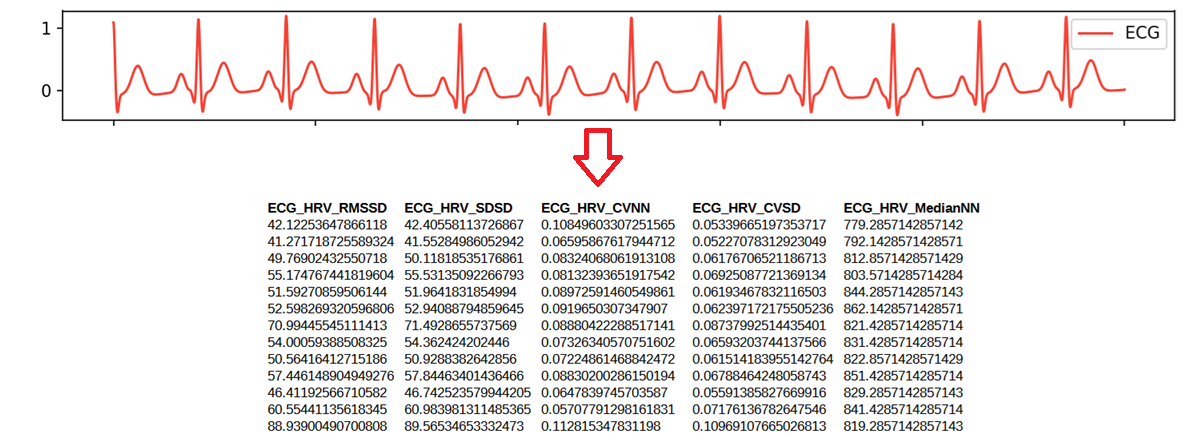

In [1]:
!pip install neurokit2

  Using cached pandas-2.3.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 21.5 MB/s  0:00:00
Using cached pandas-2.3.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 20.8 MB/s  0:00:00m0:00:01
Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any

Antes de comenzar importamos las liberías necesarias:

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
from collections import Counter

In [3]:
import neurokit2 as nk

Para esta práctica utilizaremos las siguientes constantes:

In [ ]:
# Carpeta raíz a los ficheros de los sujetos
DATA_PATH = "./multimodal_dataset"

# Lista de sujetos a procesar
SUBJECTS = ["S2", "S3", "S4", "S5", "S6", "S7", "S8",
            "S9", "S10", "S11", "S13", "S14", "S15", "S16", "S17"]

# Ventanas
WINDOW_LENGTH_SEC = 120 # Duración de cada ventana en segundos
WINDOW_STEP_SEC = 20 # Desplazamiento (novedad) de cada ventana en segundos

# Frecuencia de muestreo del chest RespiBAN (sensor que ha recogido las señales)
FS_CHEST = 700


# 1. Carga de ficheros

Primero necesitamos definir una función que se encargue de abrir cada uno de los ficheros de los sujetos:

In [ ]:
def load_subject_data(subject_id, data_path=DATA_PATH):
    """
    Carga y prepara los datos de un sujeto del dataset a partir del fichero SX.pkl.

    Parámetros
    ----------
    subject_id : str
        Identificador del sujeto (por ejemplo: "S2", "S3", ...).
    data_path : str, opcional
        Ruta a la carpeta raíz que contiene las subcarpetas de los sujetos (S2, S3, ...).
        Por defecto, usa el valor global DATA_PATH.

    Devuelve
    --------
    data : dict
        Diccionario cargado desde el fichero pickle del sujeto. Contiene, entre otros:
        - data["signal"]["chest"]: señales del RespiBAN (ECG, EDA, etc.).
        - data["signal"]["wrist"]: señales de la Empatica E4.
        - data["label"]: vector de etiquetas de fase a 700 Hz. Etiquetas de fase a predecir.

    """

    pkl_path = os.path.join(data_path, f"{subject_id}.pkl")

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    return data

In [ ]:
example_user_s3 = load_subject_data("S3")
example_user_s3

{'signal': {'chest': {'ACC': array([[ 7.20000029e-01, -1.38199985e-01,  3.19339991e+00],
          [ 5.68799973e-01, -2.28600025e-01,  3.18219995e+00],
          [ 3.99799943e-01, -3.13199997e-01,  2.94499993e+00],
          ...,
          [ 9.01800036e-01,  5.85999489e-02, -7.79998302e-03],
          [ 9.07400012e-01,  7.62000084e-02,  2.59995461e-03],
          [ 9.68199968e-01,  1.83400035e-01,  1.79999948e-01]]),
   'ECG': array([[-0.75663757],
          [-0.70820618],
          [-0.67396545],
          ...,
          [-0.24847412],
          [-0.18598938],
          [-0.14176941]]),
   'EMG': array([[ 0.00595093],
          [-0.0385437 ],
          [-0.04943848],
          ...,
          [-0.11604309],
          [-0.11082458],
          [-0.06486511]]),
   'EDA': array([[7.98835754],
          [7.98225403],
          [7.98339844],
          ...,
          [7.53211975],
          [7.53059387],
          [7.5340271 ]]),
   'Temp': array([[31.499023],
          [31.501953],
         

Cómo puedes observar, la función `load_subject_data` nos devuelve un diccionario con toda la información original del sujeto tal y como está almacenada en el fichero `SX.pkl`. Ese diccionario tiene, tres campos principales:

* `data["subject"]`: contiene el identificador del sujeto, por ejemplo “S2”, “S3”, etc.
* `data["label"]`: es un vector (array) 1D con una etiqueta por muestra, muestreado a 700 Hz. Cada valor indica en qué fase del protocolo estaba el participante en ese instante (baseline, stress, amusement, meditación, transición, etc.).
* `data["signal"]`: es otro diccionario que agrupa las señales fisiológicas registradas con los distintos dispositivos.


Dentro de `data["signal"]` tenemos, a su vez, dos subdiccionarios principales que corresponden a los dos sensores utilizados:

* `data["signal"]["chest"]`: señales recogidas con el dispositivo **RespiBAN** colocado en el pecho. Aquí encontramos canales como:

  * ECG (electrocardiograma)
  * RESP (respiración)
  * EMG (electromiografía)
  * TEMP (temperatura)
  * ACC (acelerómetro)
* `data["signal"]["wrist"]`: señales recogidas con la **Empatica E4** en la muñeca (BVP, EDA, temperatura, acelerómetro, etc.).

En nuestro caso, aunque el diccionario `data` contiene toda esta información multimodal, nos vamos a centrar únicamente en:

* `data["signal"]["chest"]["ECG"]` → la señal de ECG del pecho
* `data["signal"]["wrist"]["EDA"]` → la señal de EDA registrada por la Empatica E4


# 2. División en ventanas

La siguiente función es la encargada de procesar las señales en ventanas deslizantes.

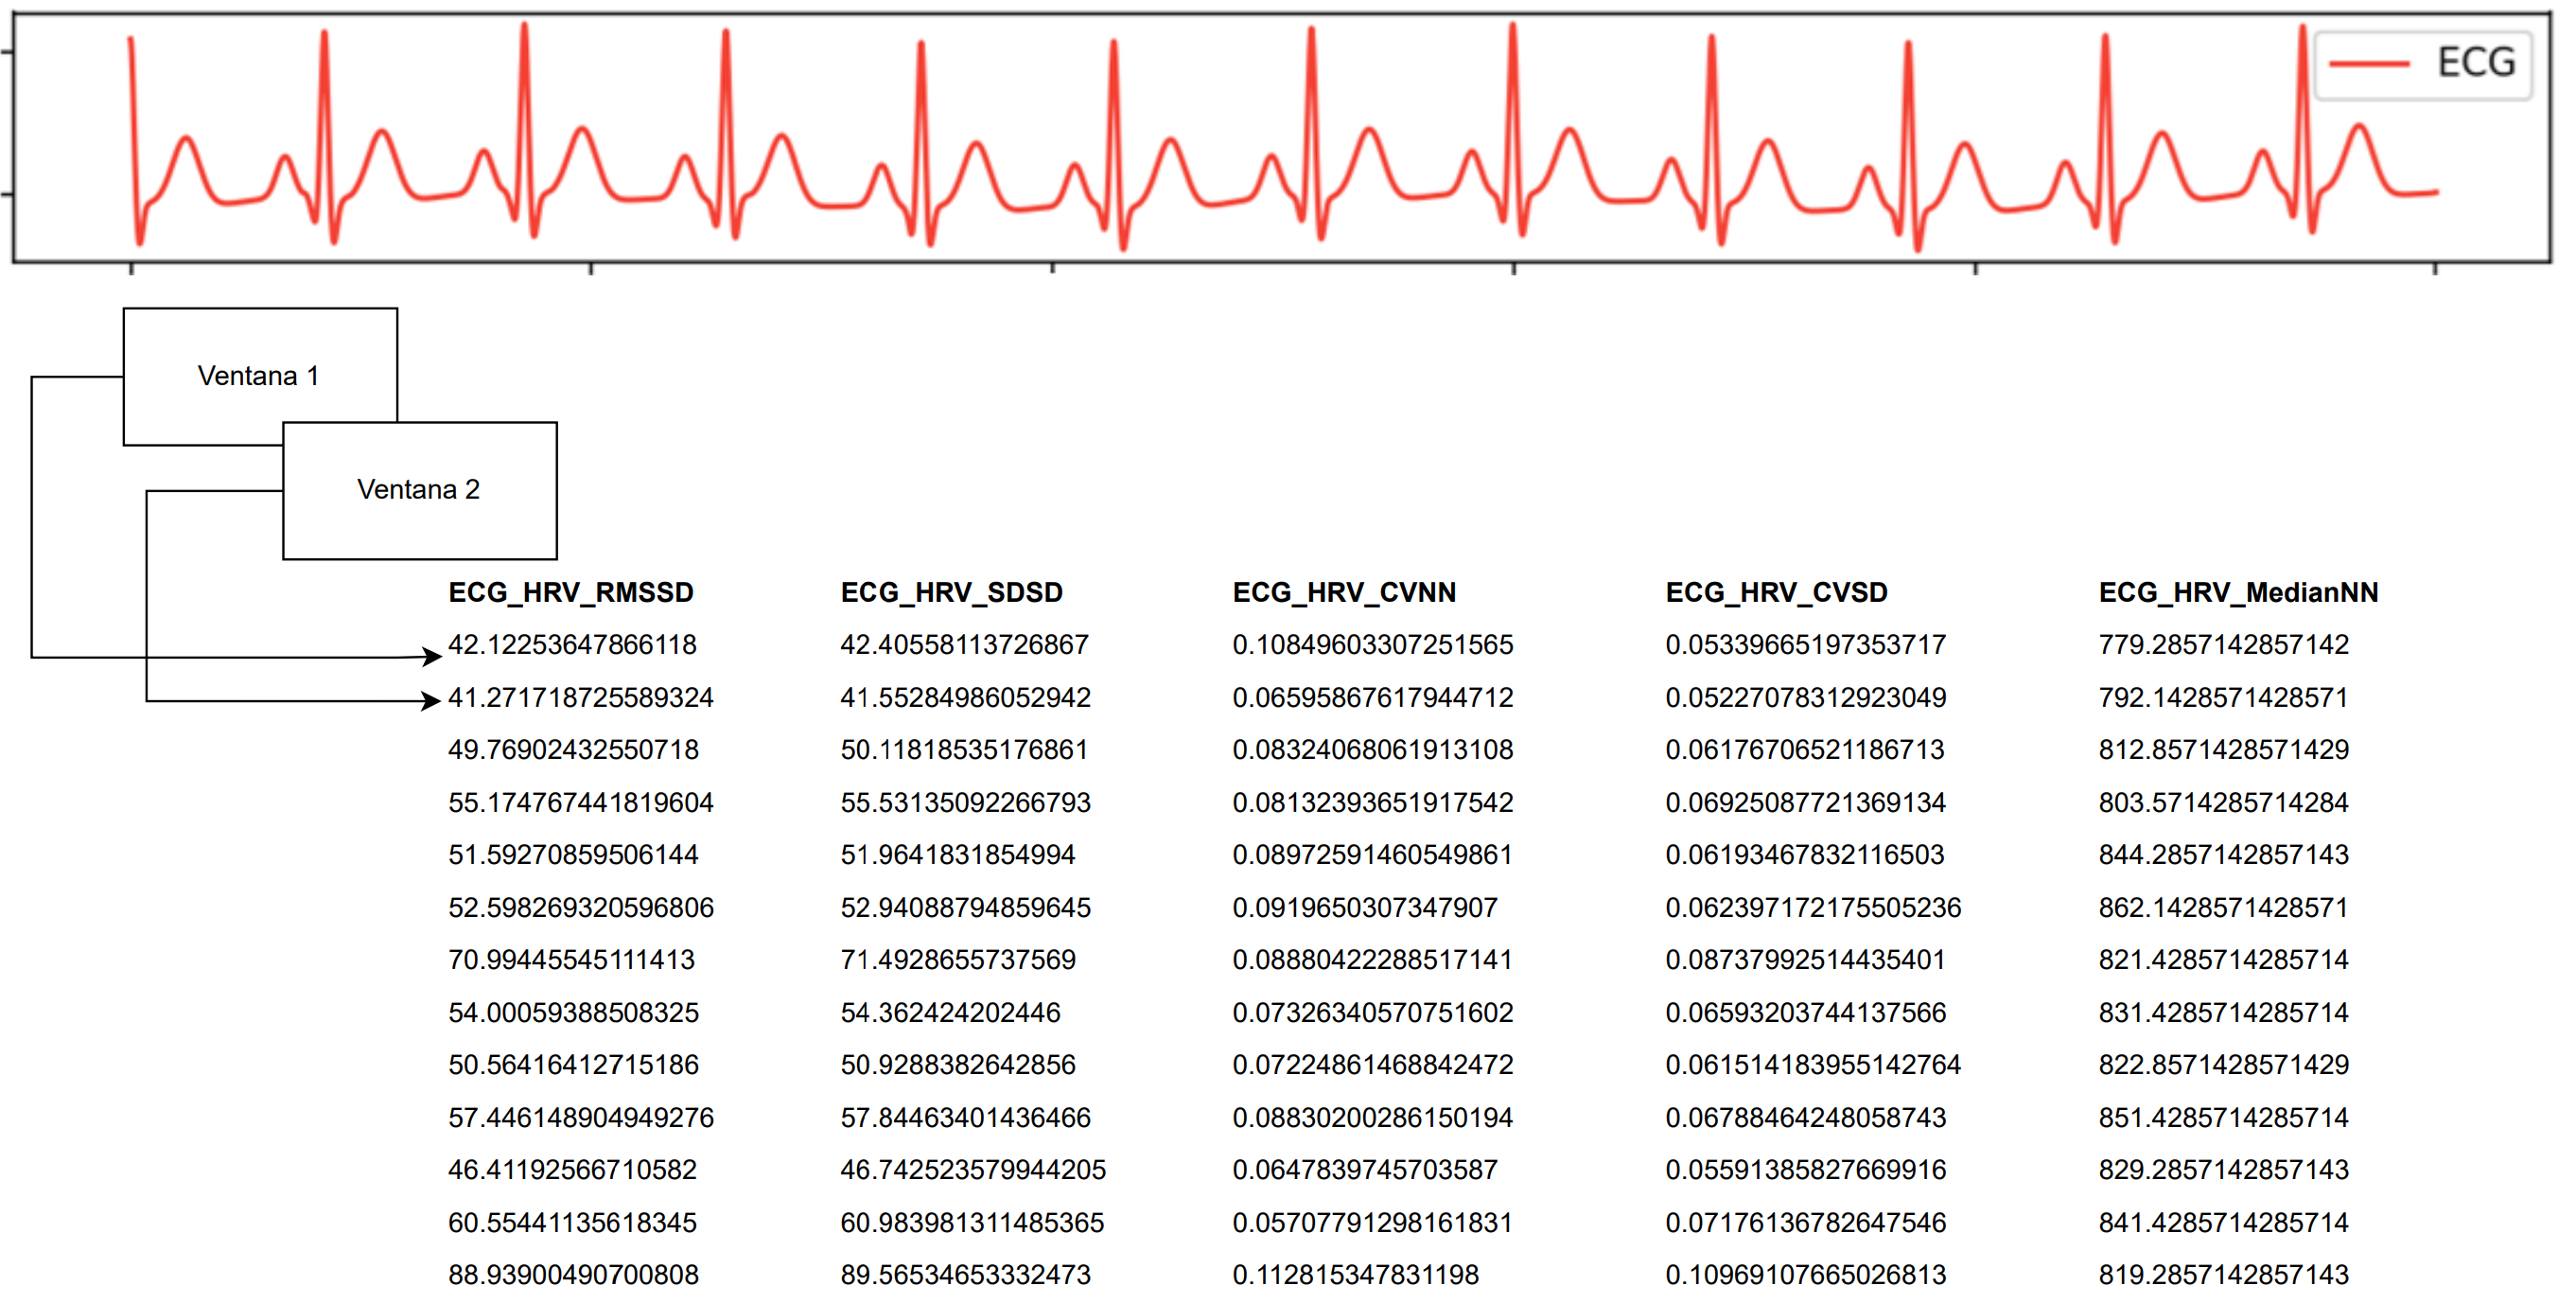

In [ ]:
def create_windows(signal_length, fs, window_length_sec, step_sec):
    """
    Genera índices de inicio y fin para segmentar una señal en ventanas temporales.

    Parámetros
    ----------
    signal_length : int
        Longitud de la señal (número de muestras).
    fs : int o float
        Frecuencia de muestreo de la señal, en Hz.
    window_length_sec : int o float
        Duración de cada ventana, en segundos.
    step_sec : int o float
        Desplazamiento entre ventanas consecutivas, en segundos.
        Si es menor que window_length_sec, se generan ventanas solapadas.

    Devuelve
    --------
    windows : list of tuple
        Lista de tuplas (start, end), donde:
        - start : int, índice de inicio de la ventana (incluido).
        - end   : int, índice de fin de la ventana (excluido).
    """
    window_size = int(window_length_sec * fs)
    step_size = int(step_sec * fs)
    windows = []

    start = 0
    while start + window_size <= signal_length:
        end = start + window_size
        windows.append((start, end))
        start += step_size

    return windows

A continuación, tienes un ejemplo de uso de la función ``create_windows``

In [ ]:
# Supongamos una señal de 10 segundos muestreada a 1 Hz (10 muestras)
fs_ejemplo = 1  # Hz
duration_ejemplo_sec = 10
signal_length_ejemplo = fs_ejemplo * duration_ejemplo_sec  # 10 muestras
signal_ejemplo = np.arange(signal_length_ejemplo)  # [0, 1, 2, ..., 9]

# Queremos ventanas de 4 segundos, con un desplazamiento o paso de 2 segundos
window_length_sec = 4
step_sec = 2

windows = create_windows(signal_length_ejemplo, fs_ejemplo, window_length_sec, step_sec)

print("Longitud de la señal:", signal_length_ejemplo)
print("Señal:", signal_ejemplo)
print("Ventanas (start, end):", windows)

# Mostrar también el contenido de la señal en cada ventana
for i, (start, end) in enumerate(windows):
    print(f"Ventana {i}: índices {start}:{end} ->", signal_ejemplo[start:end])

Longitud de la señal: 10
Señal: [0 1 2 3 4 5 6 7 8 9]
Ventanas (start, end): [(0, 4), (2, 6), (4, 8), (6, 10)]
Ventana 0: índices 0:4 -> [0 1 2 3]
Ventana 1: índices 2:6 -> [2 3 4 5]
Ventana 2: índices 4:8 -> [4 5 6 7]
Ventana 3: índices 6:10 -> [6 7 8 9]


También necesitaremos una función auxliar que nos determine si una ventana está entre dos fases:

In [ ]:
def phase_for_window(labels_window):
    """
    Determina la fase dominante de una ventana de etiquetas, exigiendo homogeneidad.

    La ventana se considera válida solamente si:
      - Todas las muestras de la ventana tienen la misma etiqueta.

    Parámetros
    ----------
    labels_window : array-like
        Vector 1D (o lista) de etiquetas correspondientes a las muestras
        dentro de una ventana temporal.

    Devuelve
    --------
    phase_label : int o None
        - Entero con la etiqueta de la fase: 1=baseline, 2=stress...
          si la ventana es homogénea
        - None si la ventana es mixta (más de una etiqueta), está vacía
          o la etiqueta es 0 (undefined), en cuyo caso esta ventana debería descartarse.
    """
    unique = set(labels_window)

    # Ventana mixta o vacía
    if len(unique) != 1:
        return None

    phase_label = list(unique)[0]

    return int(phase_label)

# 3 Extracción de características

Una vez tenemos la señal dividida en ventanas, debemos proceder a la extracción de características. Para ello, vamos a utilizar las funciones disponibles en la librería [Neurokit 2](https://neuropsychology.github.io/NeuroKit/functions/index.html). Concretamente, vamos a procesar las señales ECG y EDA. Puedes observar cómo esta extracción de características depende de la señal que utilicemos. Estas funciones, además de requerir la señal recogida por el sensor, necesitan conocer la frecuencia de muestreo del mismo.

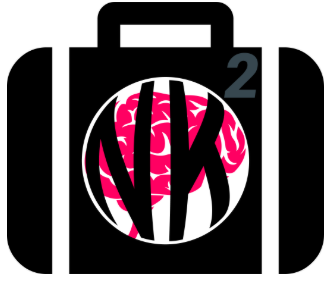

Dentro de cada una de las funciones observarás que hay manejo de excepciones. Esto se debe a que es probable que, en alguna ventana, la señal contenga ruido, por ejemplo debido al movimiento del estudiante. Por ello, en algunas situaciones es posible que no se puedan extraer características y que necesitemos ignorar una ventana.

In [ ]:
def extract_features_window_ecg(ecg_segment, fs):
    """
    Extrae características (features) de ECG para una ventana usando NeuroKit2.

    El procedimiento básico es:
      1. Limpiar la señal ECG con nk.ecg_clean().
      2. Detectar picos R con nk.ecg_peaks().
      3. Calcular índices de variabilidad de la frecuencia cardiaca (HRV)
         tanto en dominio temporal como frecuencial mediante:
         - nk.hrv_time()
         - nk.hrv_frequency()

    Parámetros
    ----------
    ecg_segment : array-like
        Segmento 1D de la señal ECG correspondiente a una ventana temporal.
    fs : int o float
        Frecuencia de muestreo del ECG, en Hz.

    Devuelve
    --------
    features : dict
        Diccionario con las características extraídas para la ventana.
        Las claves tienen el prefijo "ECG_" seguido del nombre de la métrica,
        por ejemplo:
          - "ECG_SDNN", "ECG_RMSSD", "ECG_HF", "ECG_LF", etc.
        Si ocurre algún problema (p.ej. muy pocos latidos detectados
        o error interno de NeuroKit2), se devuelve un diccionario vacío {}.
    """
    try:
        # Limpieza de ECG
        ecg_cleaned = nk.ecg_clean(ecg_segment, sampling_rate=fs)

        # Detección de picos R
        _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs)

        # Algunas ventanas pueden tener pocos latidos, protegemos esto
        if len(rpeaks.get("ECG_R_Peaks", [])) < 2:
            return {}

        # HRV – dominio temporal
        hrv_time = nk.hrv_time(rpeaks, sampling_rate=fs, show=False)

        # HRV – dominio frecuencial
        hrv_freq = nk.hrv_frequency(rpeaks, sampling_rate=fs, show=False)

        features = {}

        # Aplanar HRV time-domain
        for col in hrv_time.columns:
            features[f"ECG_{col}"] = float(hrv_time.iloc[0][col])

        # Aplanar HRV freq-domain
        for col in hrv_freq.columns:
            features[f"ECG_{col}"] = float(hrv_freq.iloc[0][col])

        return features

    except Exception:
        # Si algo falla (p.ej. señal muy ruidosa), devolvemos dict vacío
        return {}


def extract_features_window_eda(eda_segment, fs):
    """
    Extrae características (features) de EDA para una ventana usando NeuroKit2.

    El procedimiento básico es:
      1. Limpiar la señal de EDA con nk.eda_clean().
      2. Procesarla con nk.eda_process() para obtener componentes tónico/fásico.
      3. Calcular características resumen de la ventana con nk.eda_intervalrelated().

    Parámetros
    ----------
    eda_segment : array-like
        Segmento 1D de la señal EDA correspondiente a una ventana temporal.
    fs : int o float
        Frecuencia de muestreo de la señal EDA, en Hz.

    Devuelve
    --------
    features : dict
        Diccionario con las características extraídas para la ventana.
        Las claves tienen el prefijo "EDA_" seguido del nombre de la métrica,
        por ejemplo:
          - "EDA_nSCR", "EDA_PhasicMax", "EDA_TonicMean", etc.
        Si ocurre algún problema (p.ej. error de limpieza o de procesado),
        se devuelve un diccionario vacío {}.
    """
    try:
        eda_cleaned = nk.eda_clean(eda_segment, sampling_rate=fs)
        eda_signals, _ = nk.eda_process(eda_cleaned, sampling_rate=fs)

        eda_features = nk.eda_intervalrelated(eda_signals)
        features = {}

        for col in eda_features.columns:
            features[f"EDA_{col}"] = float(eda_features.iloc[0][col])

        return features

    except Exception:
        return {}

# 4. Procesamiento de un estudiante

Una vez tenemos el procesamiento en ventanas y la extracción de características, definimos la función `process_subject`. Esta función se encargará de cargar los datos de un estudiante, dividir en ventanas las señales ECG y EDA recogidas por los dispositivos correspondientes y, posteriormente, extraer las características obtenidas de cada señal y concatenarlas. **Esta concatenación permitirá su uso para una fusión temprana o a nivel de características.**

In [ ]:
def process_subject(subject_id):
    """
    Procesa un sujeto de nuestro dataset y construye un DataFrame de features por ventana.

    Pasos principales:
      - Cargar datos y etiquetas del sujeto (ECG y EDA del chest / RespiBAN).
      - Alinear ECG, EDA y labels a la misma longitud.
      - Segmentar la señal en ventanas temporales (definidas por WINDOW_LENGTH_SEC y
        WINDOW_STEP_SEC).
      - Filtrar ventanas que sean homogéneas en cuanto a fase (misma etiqueta
        y distinta de 0, usando phase_for_window).
      - Extraer features de ECG y EDA para cada ventana válida.
      - Construir un DataFrame donde cada fila corresponde a una ventana,
        con columnas de features y metadatos (por ahora: subject_id y phase_label).

    Parámetros
    ----------
    subject_id : str
        Identificador del sujeto (por ejemplo: "S2", "S3", ...).

    Devuelve
    --------
    df_subject : pandas.DataFrame
        DataFrame con una fila por ventana válida del sujeto. Sus columnas incluyen:
          - Features de ECG con prefijo "ECG_".
          - Features de EDA con prefijo "EDA_".
          - Columna "subject_id" con el ID del sujeto.
          - Columna "phase_label" con la etiqueta de la fase homogénea de la ventana.
        Si ninguna ventana es válida o ocurren problemas, puede devolver
        un DataFrame vacío (sin filas).
    """
    print(f"Procesando sujeto {subject_id}...")

    data = load_subject_data(subject_id)

    # ECG y EDA de RespiBAN (chest)
    ecg = np.array(data["signal"]["chest"]["ECG"]).squeeze()
    eda = np.array(data["signal"]["chest"]["EDA"]).squeeze()
    labels = np.array(data["label"]).squeeze()


    # Asegurar que las tres señales tienen la misma longitud
    min_len = min(len(ecg), len(eda), len(labels))
    ecg = ecg[:min_len]
    eda = eda[:min_len]
    labels = labels[:min_len]

    # Crear ventanas sobre la longitud mínima
    windows = create_windows(
        signal_length=min_len,
        fs=FS_CHEST,
        window_length_sec=WINDOW_LENGTH_SEC,
        step_sec=WINDOW_STEP_SEC,
    )

    rows = []

    # Procesamiento por cada ventana
    for (start, end) in windows:
        ecg_segment = ecg[start:end]
        eda_segment = eda[start:end]
        labels_segment = labels[start:end]

        # Fase homogénea en la ventana
        phase_label = phase_for_window(labels_segment)
        if phase_label is None:
            # Ventana entre fases, mixta o undefined: se descarta
            continue

        # Extraer features de ECG y EDA
        ecg_feats = extract_features_window_ecg(ecg_segment, fs=FS_CHEST)
        eda_feats = extract_features_window_eda(eda_segment, fs=FS_CHEST)

        # Si no hay ninguna feature puede omitirse la ventana
        if not ecg_feats and not eda_feats:
            continue

        row = {}
        row.update(ecg_feats)
        row.update(eda_feats)
        row["subject_id"] = subject_id
        row["phase_label"] = phase_label

        rows.append(row)

    # Devolvemos un dataframe con todas las ventanas de un usuario
    df_subject = pd.DataFrame(rows)
    return df_subject

# 5. Procesamiento global

Finalmente, definimos una función para procesar los datos de todos los estudiantes. Para ello, llamamos a la función `process_subject` para cada uno de los sujetos de nuestro conjunto de datos y unimos los resultados en un único dataframe final.

In [ ]:

def build_full_dataset():
    """
    Procesa todos los sujetos definidos en SUBJECTS y concatena sus resultados.

    Para cada sujeto en la lista SUBJECTS:
      - Llama a process_subject(subject_id) para generar el DataFrame de ese sujeto.
      - Añade el DataFrame resultante a una lista.
    Finalmente concatena todos los DataFrames en uno solo.

    Parámetros
    ----------
    (ninguno)
        Utiliza la lista global SUBJECTS y las funciones auxiliares.

    Devuelve
    --------
    full_df : pandas.DataFrame
        DataFrame con los datos combinados de todos los sujetos.
        Contiene las mismas columnas que df_subject (features ECG/EDA, subject_id,
        phase_label), pero con las filas de todos los sujetos concatenadas.
        Si no se ha podido generar información de ningún sujeto, devuelve
        un DataFrame vacío (sin filas).
    """
    dfs = []
    for subj in SUBJECTS:
        df_subj = process_subject(subj)
        dfs.append(df_subj)

    if len(dfs) == 0:
        return pd.DataFrame()

    full_df = pd.concat(dfs, ignore_index=True)
    return full_df


A continuación, realizamos la extracción de características y almacenamos el dataframe final en un fichero .csv. Este procesamiento es bastante costoso a nivel computacional, por lo que es mejor no repetirlo si no es necesario.

In [ ]:
full_df = build_full_dataset()
print("Shape final del dataset:", full_df.shape)
print(full_df.head())

# Guardar a CSV
output_path = "df_caracteristicas_extraidas.csv"
full_df.to_csv(output_path, index=False)
print(f"Dataset guardado en: {output_path}")

Procesando sujeto S2...
Procesando sujeto S3...
Procesando sujeto S4...
Procesando sujeto S5...
Procesando sujeto S6...
Procesando sujeto S7...
Procesando sujeto S8...
Procesando sujeto S9...
Procesando sujeto S10...
Procesando sujeto S11...
Procesando sujeto S13...
Procesando sujeto S14...
Procesando sujeto S15...
Procesando sujeto S16...
Procesando sujeto S17...
Shape final del dataset: (3072, 43)
   ECG_HRV_MeanNN  ECG_HRV_SDNN  ECG_HRV_SDANN1  ECG_HRV_SDNNI1  \
0      789.895238     70.512456             NaN             NaN   
1      792.457143     68.756366             NaN             NaN   
2      787.691580     65.694171             NaN             NaN   
3      797.866795     60.212382             NaN             NaN   
4      803.368726     63.630940             NaN             NaN   

   ECG_HRV_SDANN2  ECG_HRV_SDNNI2  ECG_HRV_SDANN5  ECG_HRV_SDNNI5  \
0             NaN             NaN             NaN             NaN   
1             NaN             NaN             NaN       